<a href="https://colab.research.google.com/github/nicholas-schwier-class/Computational-Probability-and-Stats-2026/blob/main/Ch7_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Example Context: Daily Coffee Spending

A student buys coffee on campus many days during the semester. The amount spent each day varies, but there is a true average daily spending level.

The Law of Large Numbers tells us:

If we observe more and more days, the sample average spending will get closer to the true average daily spending.

Suppose daily spending follows a normal distribution:

X∼N(4.50,1.20)

Where

X = daily coffee spending (dollars)

μ=4.50 = population mean spending

σ=1.20 = population standard deviation

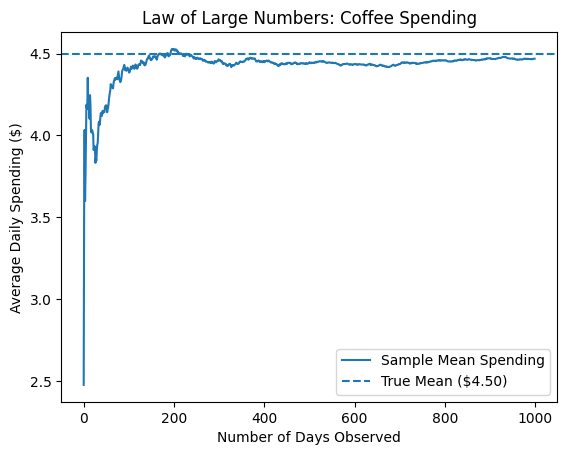

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# True population parameters
true_mean = 4.50
std_dev = 1.20

# Number of days
n = 1000

# Simulate daily coffee spending
spending = np.random.normal(true_mean, std_dev, n)

# Running sample mean
sample_mean = np.cumsum(spending) / np.arange(1, n + 1)

# Plot the convergence
plt.figure()

plt.plot(sample_mean, label="Sample Mean Spending")

plt.axhline(true_mean, linestyle="--", label="True Mean ($4.50)")

plt.xlabel("Number of Days Observed")
plt.ylabel("Average Daily Spending ($)")
plt.title("Law of Large Numbers: Coffee Spending")

plt.legend()

plt.show()

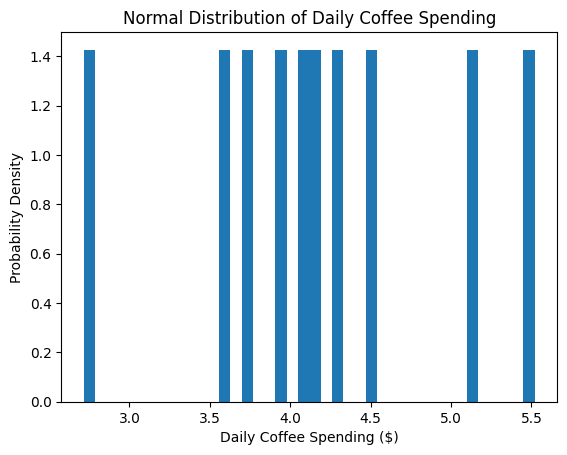

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Population parameters
mu = 4.50
sigma = 1.20

# Simulate 10 days of spending
data = np.random.normal(mu, sigma, 10)

# Simulate 10000 days of spending
#data = np.random.normal(mu, sigma, 10000)

# Plot histogram
plt.figure()

plt.hist(data, bins=40, density=True)

plt.xlabel("Daily Coffee Spending ($)")
plt.ylabel("Probability Density")
plt.title("Normal Distribution of Daily Coffee Spending")

plt.show()

Customer Purchase Amounts in an Online Store
Scenario

Suppose an online store records the amount spent per customer order.

Order amounts are typically right skewed because:

Many customers buy small items

Some customers place very large orders

To model this, we use an exponential distribution (a common skewed distribution).

Population assumption:

μ=50

Average order value is $50.

We will simulate:

1. Individual purchases (skewed distribution)

2. Sample means of many random samples

3. Show that the distribution of the sample means becomes normal

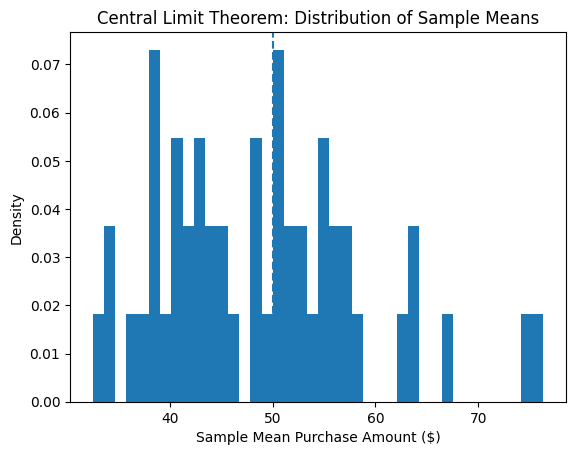

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Population parameters
population_mean = 50

# Number of simulations
num_samples = 50

# Sample size
n = 30

# Store sample means
sample_means = []

for i in range(num_samples):

    # Generate one random sample (skewed distribution)
    sample = np.random.exponential(population_mean, n)

    # Compute sample mean
    sample_mean = np.mean(sample)

    sample_means.append(sample_mean)

sample_means = np.array(sample_means)

# Plot distribution of sample means
plt.figure()

plt.hist(sample_means, bins=40, density=True)

plt.axvline(population_mean, linestyle="--")

plt.xlabel("Sample Mean Purchase Amount ($)")
plt.ylabel("Density")
plt.title("Central Limit Theorem: Distribution of Sample Means")

plt.show()

Restaurant Delivery Times

Suppose a restaurant tracks delivery times (minutes).

Delivery times are always non negative, so Markov's inequality can apply.

Assume:

Average delivery time
E[X]=30 minutes

We want to estimate the probability that delivery takes 60 minutes or more

In [8]:
import numpy as np

# Simulate delivery times (minutes)
# Exponential distribution often models waiting times
delivery_times = np.random.exponential(scale=30, size=10000)

# Compute empirical mean
mean_delivery = np.mean(delivery_times)

# Threshold value
a = 60

# Empirical probability
empirical_probability = np.mean(delivery_times >= a)

# Markov bound
markov_bound = mean_delivery / a

print("Average delivery time:", mean_delivery)
print("Actual P(X >= 60):", empirical_probability)
print("Markov bound:", markov_bound)

Average delivery time: 30.360145334279146
Actual P(X >= 60): 0.1391
Markov bound: 0.5060024222379857


Markov's inequality does not estimate the exact probability.

Instead, it provides a guaranteed upper bound when we know only the mean.

This makes it useful when:

Distribution is unknown

Data is limited

Only the expected value is available

Conceptual Overview

Chebyshev's Inequality gives a bound on the probability that a value lies far from the mean.

Chebyshev's inequality does not assume a normal distribution. It works for any distribution with a finite mean and variance.

Suppose we analyze daily commute times to work (minutes) for employees in a large company.

Assume the following summary statistics:

Mean commute time:

μ=35 minutes

Standard deviation:


σ=10 minutes

We want to check Chebyshev's inequality for

k=2.

In [9]:
import numpy as np

# Simulate commute times (minutes)
# Gamma distribution often models waiting or travel times
commute_times = np.random.gamma(shape=4, scale=9, size=10000)

# Compute sample statistics
mean_time = np.mean(commute_times)
std_time = np.std(commute_times)

# Choose k = 2
k = 2

# Compute interval bounds
lower = mean_time - k * std_time
upper = mean_time + k * std_time

# Proportion within interval
within_interval = np.mean((commute_times >= lower) & (commute_times <= upper))

# Chebyshev bound
chebyshev_bound = 1 - 1/(k**2)

print("Mean commute time:", mean_time)
print("Standard deviation:", std_time)
print("Interval:", lower, "to", upper)
print("Actual proportion within interval:", within_interval)
print("Chebyshev minimum bound:", chebyshev_bound)

Mean commute time: 36.009142238460335
Standard deviation: 18.070815519606466
Interval: -0.13248880075259706 to 72.15077327767327
Actual proportion within interval: 0.9584
Chebyshev minimum bound: 0.75
